---
## This plot will create "Figure 2" for the paper draft of Feb '26
##### Noel Siegert, 2/25/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'Fig2_submissionFeb26.ipynb'

In [5]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [6]:
# open hw data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!

# thw
thw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.heatwaves.nc')

# analysis - computing changes and trends in concurrent MHW-THW days

In [7]:
## Daily scale

# concurrent MHW-THW days
con_mhwthwdays = hw_ds.MHW * thw_ds.THW

mhw_mask = hw_ds.MHW
thw_mask = thw_ds.THW

# gen standalone DAYS 
mhw_standalone_mask = (mhw_mask * np.logical_not(thw_mask))
thw_standalone_mask = (thw_mask * np.logical_not(mhw_mask))


## monthly scale

# aggregate to monthly scale, and make 12-month rolling averages
mhw_standalone_mo = mhw_standalone_mask.sum(dim='staid').resample(time='MS').sum()
thw_standalone_mo = thw_standalone_mask.sum(dim='staid').resample(time='MS').sum()
con_mo = con_mhwthwdays.sum(dim='staid').resample(time='MS').sum()

mhw_standalone_mo_r12 = mhw_standalone_mo.rolling(time=12).mean()
thw_standalone_mo_r12 = thw_standalone_mo.rolling(time=12).mean()
con_mo_r12 = con_mo.rolling(time=12).mean()

ratio_con_v_thw_mo = (con_mhwthwdays.sum(dim='staid').resample(time='MS').sum() / thw_standalone_mo)
ratio_con_v_mhw_mo = (con_mhwthwdays.sum(dim='staid').resample(time='MS').sum() / mhw_standalone_mo)

ratio_con_v_thw_ann_bysta = (con_mhwthwdays.resample(time='YS').sum(dim='time') / thw_standalone_mask.resample(time='YS').sum(dim='time')).where(thw_standalone_mask.resample(time='YS').sum(dim='time')>0)
ratio_con_v_mhw_ann_bysta = (con_mhwthwdays.resample(time='YS').sum(dim='time') / mhw_standalone_mask.resample(time='YS').sum(dim='time')).where(mhw_standalone_mask.resample(time='YS').sum(dim='time')>0)
    # what to do about a) yr where there are no concurrent days? ==> set ratio to 0. 0/x = 0
    # what to do about b) yr where there are no THW/denominator? ==> set as NaN? --> done

ratio_con_v_thw_mo_r12 = ratio_con_v_thw_mo.rolling(time=12).mean()
ratio_con_v_mhw_mo_r12 = ratio_con_v_mhw_mo.rolling(time=12).mean()

# express as percent changes
thw_standalone_mo_pct = ((thw_standalone_mo-thw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / thw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100
mhw_standalone_mo_pct = ((mhw_standalone_mo-mhw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / mhw_standalone_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100
con_mo_pct = ((con_mo-con_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) / con_mo.sel(time=slice('1990-01-01', '1990-12-31')).mean()) * 100

thw_standalone_mo_pct_r12 = thw_standalone_mo_pct.rolling(time=12).mean()
mhw_standalone_mo_pct_r12 = mhw_standalone_mo_pct.rolling(time=12).mean()
con_mo_pct_r12 = con_mo_pct.rolling(time=12).mean()


## Annual scale

mhwdays_ann = hw_ds.MHW.resample(time='YS').sum()
thwdays_ann = thw_ds.THW.resample(time='YS').sum()
con_mhwthwdays_ann = con_mhwthwdays.resample(time='YS').sum()

mhw_standalone_ann = mhw_standalone_mask.resample(time='YS').sum(dim='time')
thw_standalone_ann = thw_standalone_mask.resample(time='YS').sum(dim='time')

# fraction of THW days that are also concurrent days
conHW_thw_ann = (con_mhwthwdays_ann / thwdays_ann)

# fraction of MHW days that are also concurrent days
conHW_mhw_ann = (con_mhwthwdays_ann / mhwdays_ann)

In [8]:
## global sums
con_mhwthwdays_ann_global = con_mhwthwdays_ann.sum(dim='staid')
mhw_standalone_ann_global = mhw_standalone_ann.sum(dim='staid')
thw_standalone_ann_global = thw_standalone_ann.sum(dim='staid')

In [9]:
# get changes in n. concurrent, and ∆'s in ratio's of concurrent/standalone

delta_con_days = (con_mhwthwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - con_mhwthwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_mhw_days = (mhwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - mhwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_thw_days = (thwdays_ann.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - thwdays_ann.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))

delta_ratio_con_v_thw = (ratio_con_v_thw_ann_bysta.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - ratio_con_v_thw_ann_bysta.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))
delta_ratio_con_v_mhw = (ratio_con_v_mhw_ann_bysta.sel(time=slice('2014-01-01', '2023-12-31')).mean(dim='time') - ratio_con_v_mhw_ann_bysta.sel(time=slice('1990-01-01', '1999-12-31')).mean(dim='time'))

In [10]:
# calculate r(con, mhw), r(con, thw) and r(thw, mhw)

rconmhw_bysta = xr.corr(con_mhwthwdays_ann, mhw_standalone_ann, dim='time')
rconthw_bysta = xr.corr(con_mhwthwdays_ann, thw_standalone_ann, dim='time')
rmhwthw_bysta = xr.corr(mhw_standalone_ann, thw_standalone_ann, dim='time')

rconmhw_global = xr.corr(con_mhwthwdays_ann_global, mhw_standalone_ann_global).item()
rconthw_global = xr.corr(con_mhwthwdays_ann_global, thw_standalone_ann_global).item()
rmhwthw_global = xr.corr(mhw_standalone_ann_global, thw_standalone_ann_global).item()


# calculate r(ratiocon, mhw), r(ratiocon, thw) and r(thw, mhw)

r_RatioConvTHW_mhw_bysta = xr.corr(ratio_con_v_thw_ann_bysta, mhw_standalone_ann, dim='time')
r_RatioConvTHW_thw_bysta = xr.corr(ratio_con_v_thw_ann_bysta, thw_standalone_ann, dim='time')

r_RatioConvMHW_mhw_bysta = xr.corr(ratio_con_v_mhw_ann_bysta, mhw_standalone_ann, dim='time')
r_RatioConvMHW_thw_bysta = xr.corr(ratio_con_v_mhw_ann_bysta, thw_standalone_ann, dim='time')

r_RatioConvTHW_mhw_global = xr.corr(con_mhwthwdays_ann_global/thw_standalone_ann.sum(dim='staid'), mhw_standalone_ann_global).item() # mhw_standalone_ann_global
r_RatioConvTHW_thw_global = xr.corr(con_mhwthwdays_ann_global/thw_standalone_ann.sum(dim='staid'), thw_standalone_ann_global).item()

r_RatioConvMHW_mhw_global = xr.corr(con_mhwthwdays_ann_global/mhw_standalone_ann.sum(dim='staid'), mhw_standalone_ann_global).item() 
r_RatioConvMHW_thw_global = xr.corr(con_mhwthwdays_ann_global/mhw_standalone_ann.sum(dim='staid'), thw_standalone_ann_global).item()

# Plot

In [11]:
# concurrent cmap
vmin = -10
vmax = 10
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = (cmap, norm, bounds)

In [12]:
# fraction/ratio cmap
vmin = -1
vmax = 1
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_r, norm_r, bounds_r = (cmap, norm, bounds)

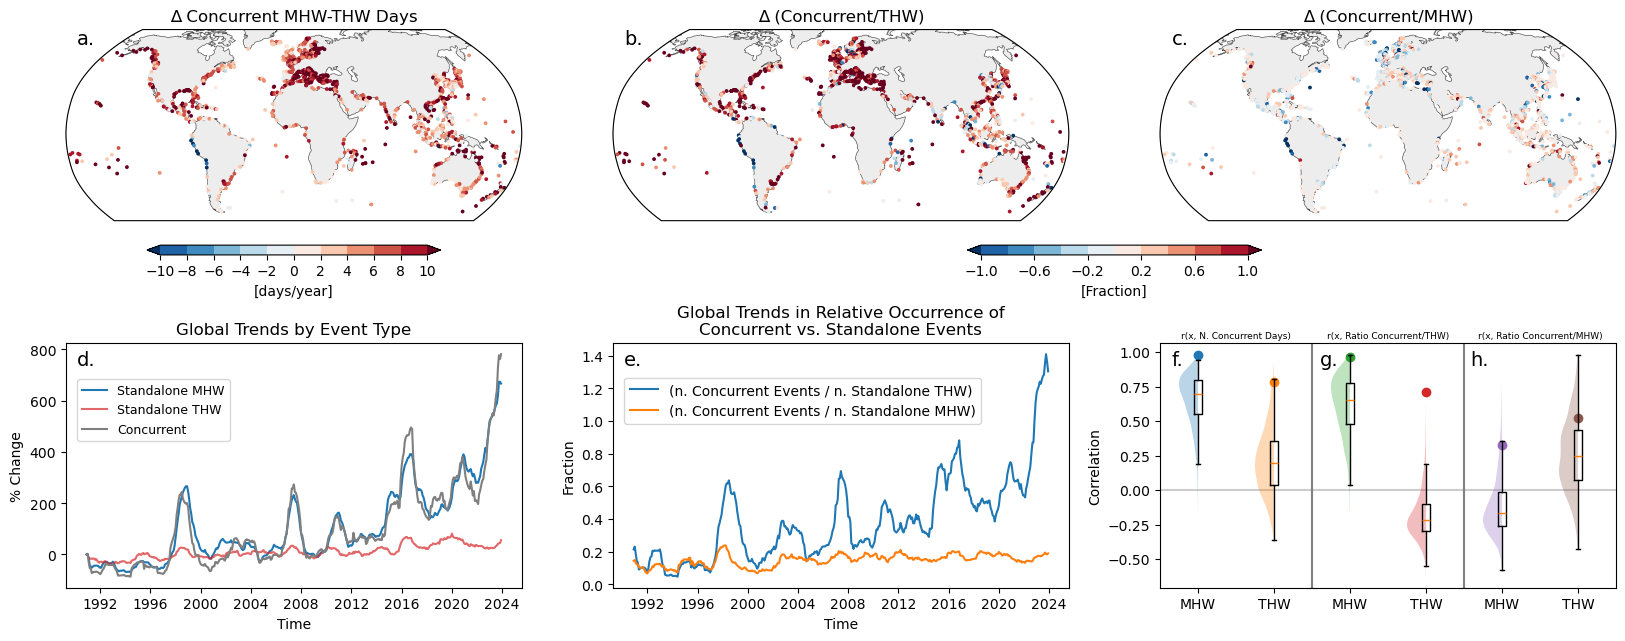

In [13]:
## PLOTTING, To SAVE figure for manuscript submission

nrows = 2
ncols = 3
fig = plt.figure(figsize=(20, 7.5))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.2, hspace=0.36)

ax00 = fig.add_subplot(gs[0,0], projection=ccrs.Robinson())
ax01 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
ax02 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
ax10 = fig.add_subplot(gs[1,0])
ax11 = fig.add_subplot(gs[1,1])
ax12 = fig.add_subplot(gs[1,2])

# ax00 - ∆ n. concurrent days
gdf.plot(delta_con_days.data, markersize=3, ax=ax00, transform=ccrs.PlateCarree(), cmap=cmap_c, norm=norm_c)
ax00.set(title='∆ Concurrent MHW-THW Days')

# ax01 - ∆ ratio con/thw
gdf.plot(delta_ratio_con_v_thw.data, markersize=3, ax=ax01, transform=ccrs.PlateCarree(), cmap=cmap_r, norm=norm_r)
ax01.set(title='∆ (Concurrent/THW)')

# ax02 - ∆ ratio con/mhw
gdf.plot(delta_ratio_con_v_mhw.data, markersize=3, ax=ax02, transform=ccrs.PlateCarree(), cmap=cmap_r, norm=norm_r)
ax02.set(title='∆ (Concurrent/MHW)')


# add a colorbar(s)
sm = plt.cm.ScalarMappable(norm=norm_c,cmap=cmap_c)
sm.set_array([])

cbar = fig.colorbar(sm, ax=[ax00], orientation='horizontal', label="[days/year]", pad=0.1, use_gridspec=True, fraction=0.04, ticks=bounds_c,
                extend='both', aspect=30)   


sm = plt.cm.ScalarMappable(norm=norm_r,cmap=cmap_r)
sm.set_array([])

cbar = fig.colorbar(sm, ax=[ax01, ax02], orientation='horizontal', label="[Fraction]", pad=0.1, use_gridspec=True, fraction=0.04, ticks=bounds_r[0::2],
                extend='both', aspect=30)   

# axis cosmetics
for aa in [ax00, ax01, ax02]:
    aa.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
    aa.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0)

    
    
# ax10 - change in event-types, in % (%∆ from 1990 value)?
mhw_standalone_mo_pct_r12.plot(ax=ax10, label='Standalone MHW', color='tab:blue', ls='-')
thw_standalone_mo_pct_r12.plot(ax=ax10, label='Standalone THW', color='tab:red', ls='-', alpha=0.7)
con_mo_pct_r12.plot(ax=ax10, label='Concurrent', color='tab:grey', ls='-')
ax10.set(xlabel='Time', ylabel='% Change', title='Global Trends by Event Type')
ax10.legend(fontsize=9, loc=(0.025, 0.6))


ratio_con_v_thw_mo_r12.plot(ax=ax11, label='(n. Concurrent Events / n. Standalone THW)', ls='-')
ratio_con_v_mhw_mo_r12.plot(ax=ax11, label='(n. Concurrent Events / n. Standalone MHW)', ls='-')
ax11.set(title='Global Trends in Relative Occurrence of\nConcurrent vs. Standalone Events', xlabel='Time', ylabel='Fraction')
ax11.legend(loc=(0.025, 0.67))


# ax12 - showing how MHW is most closely correlated with other qty's of interest. 

ax=ax12
data_list = [rconmhw_bysta[~np.isnan(rconmhw_bysta)], rconthw_bysta[~np.isnan(rconthw_bysta)],
           r_RatioConvTHW_mhw_bysta[~np.isnan(r_RatioConvTHW_mhw_bysta)], r_RatioConvTHW_thw_bysta[~np.isnan(r_RatioConvTHW_thw_bysta)],
           r_RatioConvMHW_mhw_bysta[~np.isnan(r_RatioConvMHW_mhw_bysta)], r_RatioConvMHW_thw_bysta[~np.isnan(r_RatioConvMHW_thw_bysta)]]

ax.boxplot(data_list, widths=0.1, showfliers=False)

for j, dat in enumerate(data_list):
    
    vplot = ax.violinplot(dat, showmedians=False, showextrema=False, positions=[j+1])

    # Modify paths for half-violin
    for body in vplot['bodies']:
        m = np.mean(body.get_paths()[0].vertices[:, 0])
        # Clip right side
        body.get_paths()[0].vertices[:, 0] = np.clip(body.get_paths()[0].vertices[:, 0], -np.inf, m)

# scatter on the global-scale correlations
ax.scatter(1, rconmhw_global)
ax.scatter(2, rconthw_global)
#ax.scatter(3, rmhwthw_global)
ax.scatter(3, r_RatioConvTHW_mhw_global)
ax.scatter(4, r_RatioConvTHW_thw_global)
ax.scatter(5, r_RatioConvMHW_mhw_global)
ax.scatter(6, r_RatioConvMHW_thw_global)

# cosmetics
ax.axvline(2.5, color='grey')
ax.axvline(4.5, color='grey')
ax.axhline(color='grey', alpha=0.4, zorder=0)

# tick labels, titles, etc.
ax.set_xticks(ticks=ax.get_xticks(), labels=['MHW', 'THW', 'MHW', 'THW', 'MHW', 'THW'])
ax.text(s='r(x, N. Concurrent Days)', x=1.5, y=1.1, ha='center', fontsize=6.5)
ax.text(s='r(x, Ratio Concurrent/THW)', x=3.5, y=1.1, ha='center', fontsize=6.5)
ax.text(s='r(x, Ratio Concurrent/MHW)', x=5.5, y=1.1, ha='center', fontsize=6.5)
ax.set(ylabel='Correlation')

## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f']

for i, ax in enumerate([ax00, ax01, ax02, ax10, ax11, ax12]):
    if i<3:
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
    else: 
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)

# manualy add more subplot labels
ax12.text(s='g.', x=0.35, y=0.91, transform=ax12.transAxes, ha='left', fontsize=14)
ax12.text(s='h.', x=0.68, y=0.91, transform=ax12.transAxes, ha='left', fontsize=14)

# # time & script
# now = datetime.now() # get datetime
# fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')

# SAVE FIGURE
# plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/Fig2_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()

## supplemental figure S3

In [14]:
%%time 

## regressions for every station (get linear trend in days per year)

# to hold outputs: shape = [regression, station, col=statistic (slope, intercept, rval, pval)]
nregs = 3
# the regressions: 
# reg 0: trend in concurrent MHW + THW days
# reg 1: trend in fraction of THW days with an an accompanying coastal MHW (concurrent / standalone THW)
# reg 2: trend in fraction of MHW days with an an accompanying coastal THW (concurrent / standalone MHW)
regOutArr = np.zeros(shape=(nregs, len(gdf), 4)) * np.nan 
regOutArr_w = np.zeros(shape=(nregs, len(gdf), 4)) * np.nan 
regOutArr_c = np.zeros(shape=(nregs, len(gdf), 4)) * np.nan 

# list to store all yval's for regression (reg, season)
yval_arr = [con_mhwthwdays_ann, ratio_con_v_thw_ann_bysta, ratio_con_v_mhw_ann_bysta]

# x var is the same in every regression (it's just year)
xs = np.array(range(len(con_mhwthwdays_ann.time)))

## Do the regressions
for reg in range(nregs):
    
    print('Reg. {}'.format(reg))
    
    # perform the given regression(s) at every station. 
    for stanum in range(len(gdf)):

        # get data and do regressions
        ys = yval_arr[reg][stanum,:].data
        regOutArr[reg, stanum] = stats.linregress(xs, ys)[:4]

Reg. 0
Reg. 1
Reg. 2
CPU times: user 4.48 s, sys: 28 ms, total: 4.51 s
Wall time: 4.5 s


In [15]:
## compute trends using the global mean timeseries as well

ratio_con_v_thw_ann_globalmean = ratio_con_v_thw_ann_bysta.mean(dim='staid')
ratio_con_v_mhw_ann_globalmean = ratio_con_v_mhw_ann_bysta.mean(dim='staid')

xs = np.array(range(len(ratio_con_v_thw_ann_globalmean.time)))
result0 = stats.linregress(xs, ratio_con_v_thw_ann_globalmean)[:4]
result1 = stats.linregress(xs, ratio_con_v_mhw_ann_globalmean)[:4]

con_mhwthwdays_ann_globalmean = con_mhwthwdays_ann.mean(dim='staid')
ratio_con_v_thw_ann_globalmean = ratio_con_v_thw_ann_bysta.mean(dim='staid')
ratio_con_v_mhw_ann_globalmean = ratio_con_v_mhw_ann_bysta.mean(dim='staid')

xs = np.array(range(len(ratio_con_v_thw_ann_globalmean.time)))
result000 = stats.linregress(xs, con_mhwthwdays_ann_globalmean)[:4]
result0 = stats.linregress(xs, ratio_con_v_thw_ann_globalmean)[:4]
result1 = stats.linregress(xs, ratio_con_v_mhw_ann_globalmean)[:4]

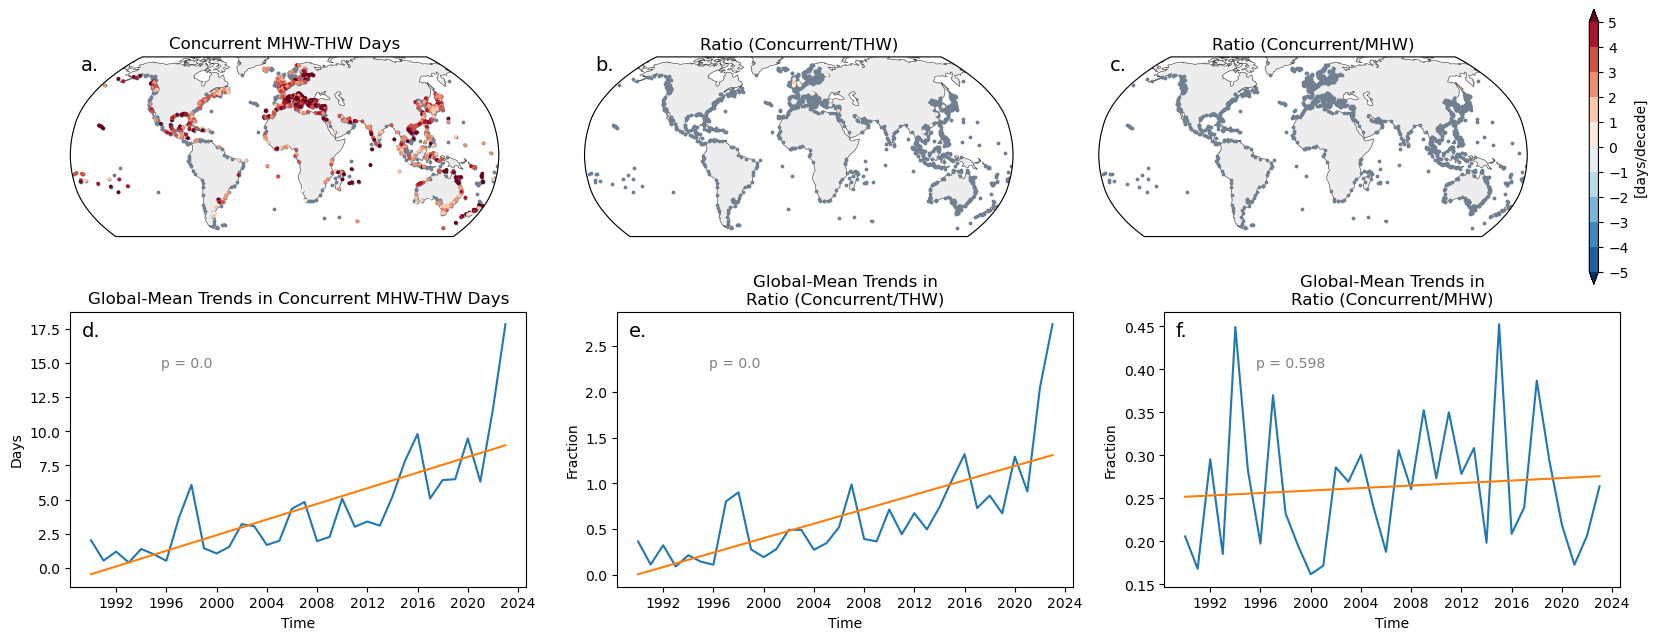

In [16]:
## plot the supplemental fig. 

# concurrent cmap
vmin = -5
vmax = 5
ncol = 11
bounds = np.linspace(vmin, vmax, ncol)
cols = plt.get_cmap('RdBu_r')(np.linspace(0,1,len(bounds)+1))
cmap = colors.ListedColormap(cols[1:-1])
cmap.set_over(cols[-1])
cmap.set_under(cols[0])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

cmap_c, norm_c, bounds_c = (cmap, norm, bounds)

## plot, saving as png

nrows = 2
ncols = 3
fig = plt.figure(figsize=(20, 7.5))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig) 
gs.update(wspace=0.2, hspace=0.1)

ax00 = fig.add_subplot(gs[0,0], projection=ccrs.Robinson())
ax01 = fig.add_subplot(gs[0,1], projection=ccrs.Robinson())
ax02 = fig.add_subplot(gs[0,2], projection=ccrs.Robinson())
ax10 = fig.add_subplot(gs[1,0])
ax11 = fig.add_subplot(gs[1,1])
ax12 = fig.add_subplot(gs[1,2])


# ax00 - trend in n. concurrent days
gdf.plot(color='slategrey', markersize=3, ax=ax00, transform=ccrs.PlateCarree())
sigmask = (regOutArr[0, :, 3] < 0.05)
gdf[sigmask].plot(regOutArr[0, sigmask, 0]*10, markersize=3, ax=ax00, transform=ccrs.PlateCarree(), cmap=cmap_c, norm=norm_c) # x10 to get decadal trend
ax00.set(title='Concurrent MHW-THW Days')

# ax01 - ∆ ratio con/thw
gdf.plot(color='slategrey', markersize=3, ax=ax01, transform=ccrs.PlateCarree())
sigmask = (regOutArr[1, :, 3] < 0.05)
gdf[sigmask].plot(regOutArr[1, sigmask, 0]*10, markersize=3, ax=ax01, transform=ccrs.PlateCarree(), cmap=cmap_c, norm=norm_c) # x10 to get decadal trend

ax01.set(title='Ratio (Concurrent/THW)')

# ax02 - ∆ ratio con/mhw ## NONE are significant so blanking out
gdf.plot(color='slategrey', markersize=3, ax=ax02, transform=ccrs.PlateCarree())
sigmask = (regOutArr[2, :, 3] < 0.05) 
#gdf[sigmask].plot(regOutArr[2, sigmask, 0]*10, markersize=3, ax=ax01, transform=ccrs.PlateCarree(), cmap=cmap_c, norm=norm_c) # x10 to get decadal trend
ax02.set(title='Ratio (Concurrent/MHW)')

# add a colorbar(s)
sm = plt.cm.ScalarMappable(norm=norm_c,cmap=cmap_c)
sm.set_array([])

cbar = fig.colorbar(sm, ax=[ax00, ax01, ax02], orientation='vertical', label="[days/decade]", pad=0.04, use_gridspec=True, fraction=0.02, ticks=bounds_c,
                extend='both', aspect=30)   

# axis cosmetics
for aa in [ax00, ax01, ax02]:
    aa.add_feature(cartopy.feature.LAND,edgecolor='black',facecolor='gainsboro',linewidth=0.4, alpha=0.5, zorder=0) 
    aa.add_feature(cartopy.feature.OCEAN,edgecolor='black',facecolor='white',linewidth=0.4, alpha=0.5, zorder=0)

    
## ax10 - significance of global trends (N. Concurrent)
ax10.plot(xs, con_mhwthwdays_ann_globalmean.data)
ax10.plot(xs, ((xs * result000[0]) + result000[1]))
ax10.set(ylabel='Days', title='Global-Mean Trends in Concurrent MHW-THW Days', xlabel='Time')
ax10.text(x=0.2, y=0.8, s='p = {}'.format(round(result000[3],4)), transform=ax10.transAxes, color='grey')


## ax11 - significance of global trends  ratio (Con/THW)
ax11.plot(xs, ratio_con_v_thw_ann_bysta.mean(dim='staid').data)
ax11.plot(xs, ((xs * result0[0]) + result0[1]))
ax11.set(ylabel='Fraction', title='Global-Mean Trends in\nRatio (Concurrent/THW)', xlabel='Time')
ax11.text(x=0.2, y=0.8, s='p = {}'.format(round(result0[3],4)), transform=ax11.transAxes, color='grey')

## ax12 - significance of global trends    ratio (Con/MHW)
ax12.plot(xs, ratio_con_v_mhw_ann_bysta.mean(dim='staid').data)
ax12.plot(xs, ((xs * result1[0]) + result1[1]))
ax12.set(ylabel='Fraction', title='Global-Mean Trends in\nRatio (Concurrent/MHW)', xlabel='Time')
ax12.text(x=0.2, y=.8, s='p = {}'.format(round(result1[3],3)), transform=ax12.transAxes, color='grey')

## set these axis x-ticks
for aa in [ax10, ax11, ax12]:
    aa.set_xticks([ 2,  6, 10, 14, 18, 22, 26, 30, 34], labels=np.array(range(1992, 2025, 4)))    
    
    
## subplot labels
letters = ['a', 'b', 'c', 'd', 'e', 'f']

for i, ax in enumerate([ax00, ax01, ax02, ax10, ax11, ax12]):
    if i<3:
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.925, transform=ax.transAxes, ha='left', fontsize=14)
    else: 
        ax.text(s='{}.'.format(letters[i]), x=0.025, y=0.91, transform=ax.transAxes, ha='left', fontsize=14)

# time & script
# now = datetime.now() # get datetime
# fig.text(0.85, 0.025, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.045, script, ha='right', fontsize='x-small')


# SAVE FIGURE
#plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/FigS3_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()